# Differentiable Programming (Solutions)

This tutorial aims to take you through the basics of writing a differentiable program using PyTorch and to highlight some of the ways to use this type of tool. If you've trained a neural network, you've already written a differentiable program! 

The tutorial have 3 tasks:

1. **Task 1: Parameter Fitting** We begin with a simple example of fitting parameters of a differentiable physics simulator using gradient-based optimization. The ingredients here should look familiar, just composed in a different way.

2. **Task 2: Differentiable Pipelines** A powerful use of differentiable programming is to use physics code in conjunction with neural networks. We present a simple example how how these elements might be composed.

3. **Task 3: Sharp Edges** Not everything is nicely differentiable! What are some ways to deal with that?

This tutorials is updated based on Sean Gasiorowski's 2025 ML4FP differentiable modeling tutorials. Thank you Sean!



## Introduction: A physics model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from tqdm import tqdm

### A simple physics model

We will simulate the motion of a ball in 2D, where x represents horizontal axis and y represents vertical axis.

At time $t$, we will observe the position of the ball $\vec{x}(t)$ (not to be confused with x axis).

Based on the physics model, we can simulate:
\begin{equation}
\vec{x}(t) = \vec{x}_{0} + \vec{v}_{0}t + \frac{1}{2}\vec{a}t^2
\end{equation}

The acceleration $\vec{a}$ is a physics model parameter. One day, it can be your detector parameter or particle interaction model parameter.

$\vec{x}_{0}$ and $\vec{v}_{0}$ are the initial position and velocity of the ball. One day, they can be your particle position and momumtum.

In code: 

In [2]:
def position(t, a, x0, v0):
    return x0 + v0*t + 0.5*a*t**2

Let's define the parameter values. $\vec{a}$, $\vec{x}_0$ and $\vec{v}_0$ are 2D vectors in [x, y].

In [3]:
#Acceleration due to gravity (-9.8 m/s^2 in negative y direction)
a = np.asarray([0, -9.8])

#Initial position at (0,10) [m]
x0 = np.asarray([0,10])

#Initial velocity at (5, 10) [m/s]
v0 = np.asarray([5, 10])

Now get the trajectory of the ball by checking its position between 0 to 5 s.

In [4]:
#The trajectory will be represented by 10 equal timesteps
time_steps = np.linspace(0, 5, 10)

trajectory = []
for t_step in time_steps:
    xt = position(t_step, a, x0, v0)
    trajectory.append(xt)
    
trajectory = np.asarray(trajectory)

Let's animate the trajectory!

/sdf/home/c/cyifan/.local/lib/python3.10/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


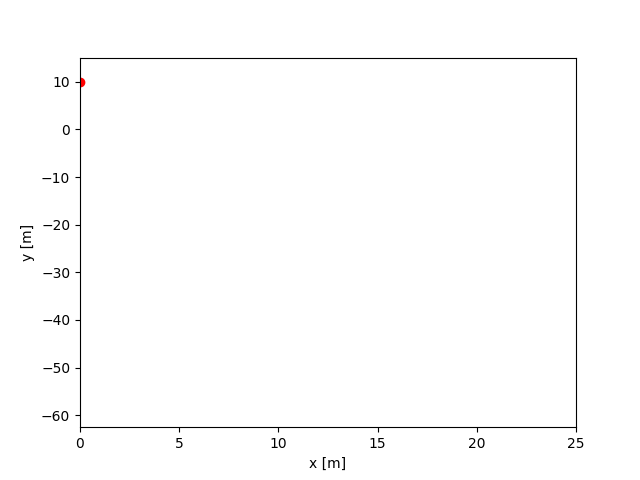

In [7]:
%matplotlib widget

fig, ax = plt.subplots()

xlim = [trajectory[:, 0].min(), trajectory[:, 0].max()]
ylim = [trajectory[:, 1].min(), trajectory[:, 1].max()]

ball, = ax.plot([x0[0]], [x0[1]], 'ro')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

def animate(time_step):
    ball.set_data([trajectory[time_step, 0]], [trajectory[time_step, 1]])
    return ball,

anim = FuncAnimation(fig, animate, frames=len(time_steps), repeat=True)
plt.show()

In [8]:
plt.close()

The same trajectory in a time collapse.

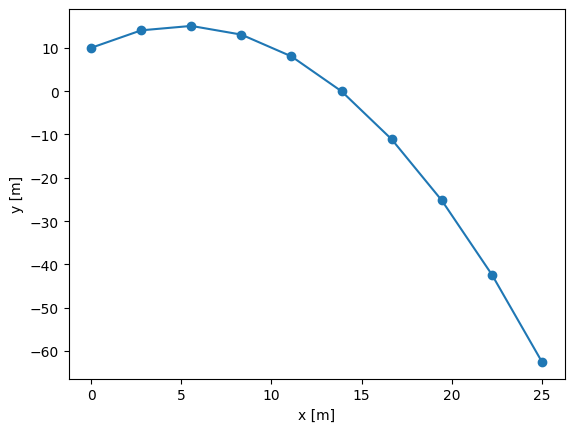

In [97]:
%matplotlib inline
plt.plot(trajectory[:, 0], trajectory[:, 1], '-o')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()

We now have a physics simulator (albeit a simple one)! 

### Terminology: 
In the ML context, we call the above simulator a **forward model**, which is similar to the physics simulation we are familiar with. Given a set of inputs/parameters, we get the model output. 
**Inverse problems** aim to recover the inputs/parameters, when you have observed data.
A **backward model** is the backward path of the forward model, which computes **gradients**. Given the observed data (model output equivalent), we backpropagate the inputs/parameters using gradients.

## Task 1: Solve the inverse problem with differentiable simulation (parameter fitting)

### Step 1: Implement the differentiable model

We'll use PyTorch for the model implementation with AD support. The same concepts apply to other framework. Feel free to build your model using alternative AD tools.

In [20]:
import torch

### Vectorization
PyTorch is a tensor library! In principle, loops work, but often slow for GPU acceleration.

We have 2D kinematic trajectory represented by `n_steps` time steps $\implies$ the output of the simulation should have shape `(n_steps, 2)`.

In [10]:
trajectory.shape

(10, 2)

Position function can stay the same!

In [11]:
def position(t, a, x0, v0):
    return x0 + v0*t + 0.5*a*t**2

However, we need to adjust the parameter shapes.
Consider the time sampling as the zeroth dimension, and spatial coordinates as the first dimension. Then, we define our parameters as:

In [11]:
#Acceleration due to gravity (-9.8 m/s^2 in negative y direction)
a = torch.tensor([0, -9.8])[None, :]

#Initial position at (0,10) [m]
x0 = torch.tensor([0,10])[None, :]

#Initial velocity at (5, 10) [m/s]
v0 = torch.tensor([5, 10])[None, :]

In [12]:
a.shape

torch.Size([1, 2])

10 timesteps between 0 to 5 s:

In [15]:
time_steps = torch.linspace(0, 5, 10)[:, None]

In [16]:
time_steps.shape

torch.Size([10, 1])

The parameters now have desired shape for the function `position()`.

In [17]:
trajectory = position(time_steps, a, x0, v0)

In [18]:
trajectory.shape

torch.Size([10, 2])

The output of the differentiable forward model is identical as the numpy implementation

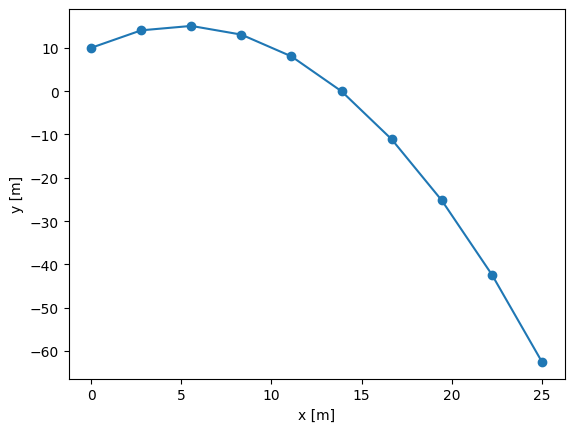

In [19]:
plt.plot(trajectory[:, 0], trajectory[:, 1], '-o')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()

Things are straightforward for now! The forward model is a single function, `position`, which takes in measurement times, acceleration, initial position, and initial velocity, and returns a trajectory ($x$ and $y$ positions at each time step).

### Step 2: Acquire data

Data is the optimization target!

We adopt an ideal scenario that the data and simulation output match. In reality, we expect differences between the data and simulation. Then the inverse problem is to optimize the model parameters or model input to align the model with data.

For now, we record the ideal trajectory data:

In [21]:
#Acceleration due to gravity (-9.8 m/s^2 in negative y direction)
a_target = torch.tensor([0, -9.8])[None, :]

#Initial position at (0,10) [m]
x0_target = torch.tensor([0,10])[None, :]

#Initial velocity at (5, 10) [m/s]
v0_target = torch.tensor([5, 10])[None, :]

#10 timesteps from 0 to 5 s
time_steps = torch.linspace(0, 5, 10)[:, None]

Data here is the trajectory that corresponds to the target parameters.

In [24]:
trajectory_data = position(time_steps, a_target, x0_target, v0_target)

### Step 3: Set initial values

To improve the physics model, we want to measure the acceleration `a`.
To start the optimization, we set all parameters according to our best knowledge.

In [27]:
#Start at (0,10) [m]
x0_sim = torch.tensor([0.,10.])[None, :]

#Initial velocity at (5, 10) [m/s]
v0_sim = torch.tensor([5., 10.])[None, :]

#Run the simulation: 10 timesteps
time_steps = torch.linspace(0, 5, 10)[:, None]

Set the parameter of interest to our "best guess".

In [26]:
a_sim = torch.tensor([0., 0.])[None, :]

This is the simulation output (forward model output) from the initial guess.

In [30]:
trajectory_sim = position(time_steps, a_sim, x0_sim, v0_sim)

### Step 4: Define a loss function

We use Mean Squared Error (MSE) between the trajectory data and the output of the forward model. Loss is very important for differentiable modeling to solve inverse problems! It needs to be **differentiable** with respect to the parameters of interest and **sensitive** to the parameter value changes.

In [31]:
loss = ((trajectory_data - trajectory_sim)**2).mean()

### Step 5: Track gradients on the parameter of interest

In PyTorch, we track gradients by setting `requires_grad = True` on the parameter of interest, such as:

In [28]:
a_sim.requires_grad = True

Gradients of `a_sim` are accessible via the attribute `a_sim.grad`. Right now, this isn't populated (we haven't done the backward autodiff pass). 

In [29]:
print(a_sim.grad)

None


Accumulate gradients from a backward pass through the loss function.

In [32]:
loss.backward()

Now `a_sim` has an associated gradient.

In [33]:
print(a_sim.grad)

tensor([[  0.0000, 357.8518]])


### Step 6: Inspect loss and gradients through scan

It is useful to inspect the loss and gradient scan as a function of the parameter value even in 1D (They are slices of high dimensional loss surfaces).

#### 1D scans for $a_x$ and $a_y$ (components of $\vec{a}$)

Vary one component while fixing the other to the nominal (the target value in closure tests).


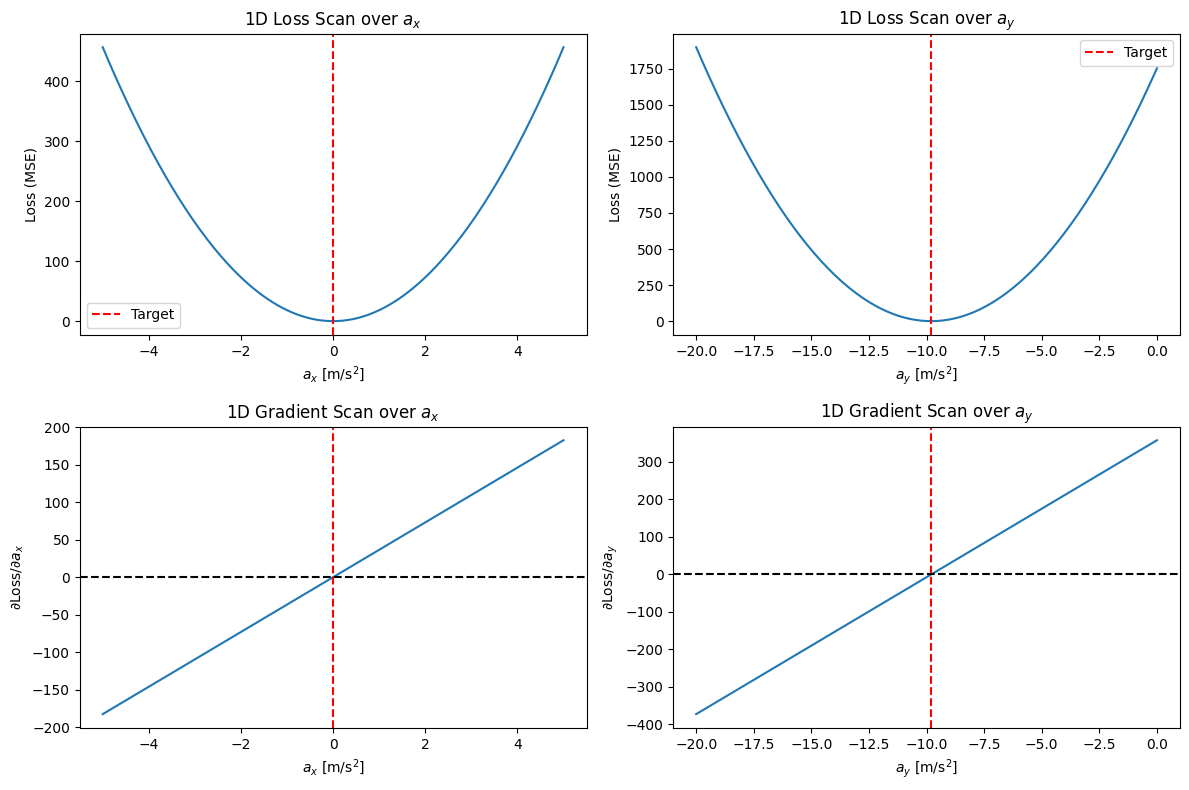

In [35]:
# loss + gradient 1D scans
def scan_1d(component='x', values=None):
    if values is None:
        values = torch.linspace(-20.0, 20.0, 200)

    losses = []
    grads = []

    for val in values:
        if component == 'x':
            a_scan = torch.tensor([[val.item(), a_target[0, 1].item()]], requires_grad=True)
        else:
            a_scan = torch.tensor([[a_target[0, 0].item(), val.item()]], requires_grad=True)

        traj_scan = position(time_steps, a_scan, x0_sim, v0_sim)
        loss_scan = ((trajectory_data - traj_scan)**2).mean()
        loss_scan.backward()

        losses.append(loss_scan.item())
        grads.append(a_scan.grad[0, 0].item() if component == 'x' else a_scan.grad[0, 1].item())

    return values.numpy(), losses, grads

# Scan a_x
a_x_scan = torch.linspace(-5.0, 5.0, 200)
ax_vals, ax_losses, ax_grads = scan_1d(component='x', values=a_x_scan)

# Scan a_y
a_y_scan = torch.linspace(-20.0, 0.0, 200)
ay_vals, ay_losses, ay_grads = scan_1d(component='y', values=a_y_scan)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(ax_vals, ax_losses)
ax[0, 0].axvline(a_target[0, 0].item(), color='r', linestyle='--', label='Target')
ax[0, 0].set_xlabel('$a_x$ [m/s$^2$]')
ax[0, 0].set_ylabel('Loss (MSE)')
ax[0, 0].set_title('1D Loss Scan over $a_x$')
ax[0, 0].legend()

ax[1, 0].plot(ax_vals, ax_grads)
ax[1, 0].axhline(0.0, color='k', linestyle='--')
ax[1, 0].axvline(a_target[0, 0].item(), color='r', linestyle='--')
ax[1, 0].set_xlabel('$a_x$ [m/s$^2$]')
ax[1, 0].set_ylabel('$\\partial$Loss/$\\partial a_x$')
ax[1, 0].set_title('1D Gradient Scan over $a_x$')

ax[0, 1].plot(ay_vals, ay_losses)
ax[0, 1].axvline(a_target[0, 1].item(), color='r', linestyle='--', label='Target')
ax[0, 1].set_xlabel('$a_y$ [m/s$^2$]')
ax[0, 1].set_ylabel('Loss (MSE)')
ax[0, 1].set_title('1D Loss Scan over $a_y$')
ax[0, 1].legend()

ax[1, 1].plot(ay_vals, ay_grads)
ax[1, 1].axhline(0.0, color='k', linestyle='--')
ax[1, 1].axvline(a_target[0, 1].item(), color='r', linestyle='--')
ax[1, 1].set_xlabel('$a_y$ [m/s$^2$]')
ax[1, 1].set_ylabel('$\\partial$Loss/$\\partial a_y$')
ax[1, 1].set_title('1D Gradient Scan over $a_y$')

plt.tight_layout()
plt.show()

#### 2D scans for $a_x$ and $a_y$ (components of $\vec{a}$)
Evaluate loss and gradient vector field over a grid in $(a_x, a_y)$.

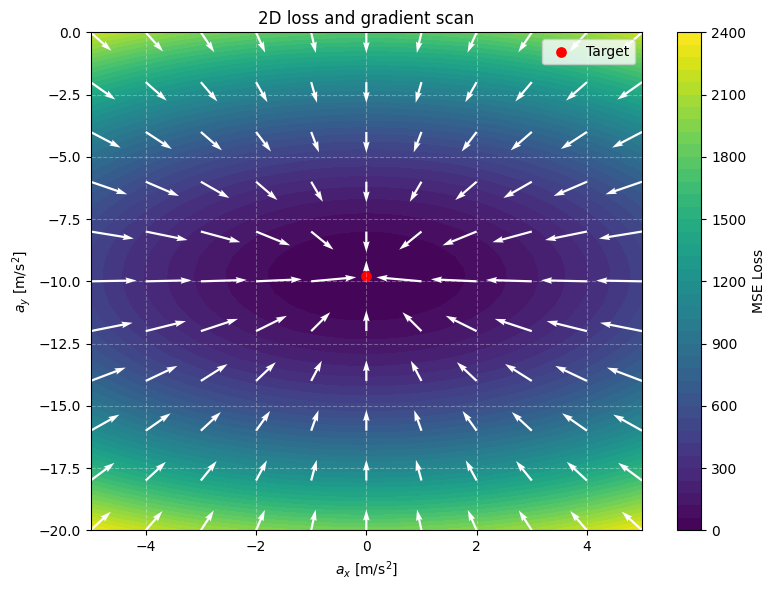

In [39]:
# 2D scan: merged loss + gradient field over (a_x, a_y)
a_x_vals = torch.linspace(-5.0, 5.0, 41)
a_y_vals = torch.linspace(-20.0, 0.0, 41)

A_X, A_Y = torch.meshgrid(a_x_vals, a_y_vals, indexing='ij')
loss_map = torch.zeros_like(A_X)
grad_ax_map = torch.zeros_like(A_X)
grad_ay_map = torch.zeros_like(A_X)

for i in range(A_X.shape[0]):
    for j in range(A_X.shape[1]):
        a_scan = torch.tensor([[A_X[i, j].item(), A_Y[i, j].item()]], requires_grad=True)
        traj_scan = position(time_steps, a_scan, x0_sim, v0_sim)
        loss_scan = ((trajectory_data - traj_scan)**2).mean()
        loss_scan.backward()

        loss_map[i, j] = loss_scan.detach()
        grad_ax_map[i, j] = a_scan.grad[0, 0].detach()
        grad_ay_map[i, j] = a_scan.grad[0, 1].detach()

fig, ax = plt.subplots(figsize=(8, 6))

# Loss surface
cont = ax.contourf(A_X.numpy(), A_Y.numpy(), loss_map.numpy(), levels=40, cmap='viridis')

skip = 4 # plot every 4th arrow for plot readability
u = -grad_ax_map[::skip, ::skip].numpy()
v = -grad_ay_map[::skip, ::skip].numpy()
mag = np.sqrt(u**2 + v**2) + 1e-12
u_norm = u / mag
v_norm = v / mag

ax.quiver(
    A_X[::skip, ::skip].numpy(),
    A_Y[::skip, ::skip].numpy(),
    u_norm,
    v_norm,
    color='white',
    angles='xy',
    scale_units='xy',
    scale=1.2,
    width=0.004,
)

ax.scatter(a_target[0, 0].item(), a_target[0, 1].item(), c='red', s=45, label='Target')
ax.set_xlabel('$a_x$ [m/s$^2$]')
ax.set_ylabel('$a_y$ [m/s$^2$]')
ax.set_title('2D loss and gradient scan')
ax.grid(True, color='white', alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(loc='upper right')

fig.colorbar(cont, ax=ax, label='MSE Loss')
plt.tight_layout()
plt.show()

Note that this physics model is differentiable out of the box, where we only used addition and multiplication. A more complicated simulation might require more attention and care (See the last part of the lecture).

### Step 7: The fit

Recall that gradient descent for some parameter (or vector of parameters) $\theta$ at training step $i$ has update rule:

\begin{equation}
\theta_{i+1} = \theta_{i} - \eta\cdot\nabla_{\theta}f(\theta_i)
\end{equation}

where $f$ is our objective function, and $\eta$ is a _learning rate_ which controls the size of the gradient step. 

Let's use this naive gradient descent as the optimizer for now.

In [45]:
# Initialize training parameters
a_sim = torch.tensor([0., 0.])[None, :]
a_sim.requires_grad = True

# Learning rate -- controls the size of the optimization step
lr = 0.02

# Keep track of training and losses 
training_path = []
losses = []
a_steps = []

# Do 10 parameter updates
for epoch in range(10):  
    
    if a_sim.grad is not None:
        a_sim.grad.zero_()
        
    # Guess with current parameters
    trajectory_sim = position(time_steps, a_sim, x0_sim, v0_sim)
    
    # Calculate loss
    loss = ((trajectory_data - trajectory_sim)**2).mean()
    
    # Compute gradients
    loss.backward()

    # Update for next loop
    # We don't want to track the gradients of a_sim for the parameter update, so we wrap it in a "with torch.no_grad()""
    with torch.no_grad():
        a_sim -= lr*a_sim.grad
        
    print(f"Iter {epoch}, loss: {loss.detach().item()}, grad: {a_sim.grad.detach().numpy()}, a_sim: {a_sim.detach().numpy()}")
    training_path.append(trajectory_sim.detach())
    losses.append(loss.item())
    a_steps.append(a_sim.detach().clone())

Iter 0, loss: 1753.473876953125, grad: [[  0.     357.8518]], a_sim: [[ 0.       -7.157036]]
Iter 1, loss: 127.53507995605469, grad: [[ 0.      96.50913]], a_sim: [[ 0.       -9.087218]]
Iter 2, loss: 9.275991439819336, grad: [[ 0.       26.027578]], a_sim: [[ 0.      -9.60777]]
Iter 3, loss: 0.6746675372123718, grad: [[0.        7.0193753]], a_sim: [[ 0.        -9.7481575]]
Iter 4, loss: 0.04907054826617241, grad: [[0.        1.8930585]], a_sim: [[ 0.       -9.786018]]
Iter 5, loss: 0.0035692634992301464, grad: [[0.        0.5105554]], a_sim: [[ 0.       -9.796229]]
Iter 6, loss: 0.0002595787518657744, grad: [[0.         0.13768548]], a_sim: [[ 0.       -9.798983]]
Iter 7, loss: 1.8897542759077623e-05, grad: [[0.         0.03714978]], a_sim: [[ 0.       -9.799726]]
Iter 8, loss: 1.3758348131887033e-06, grad: [[0.        0.0100239]], a_sim: [[ 0.       -9.799926]]
Iter 9, loss: 1.0098487734921946e-07, grad: [[0.         0.00271569]], a_sim: [[ 0.      -9.79998]]


It is very similar to training neural networks (Tutorial 01.1)!

Let's visualise the loss:

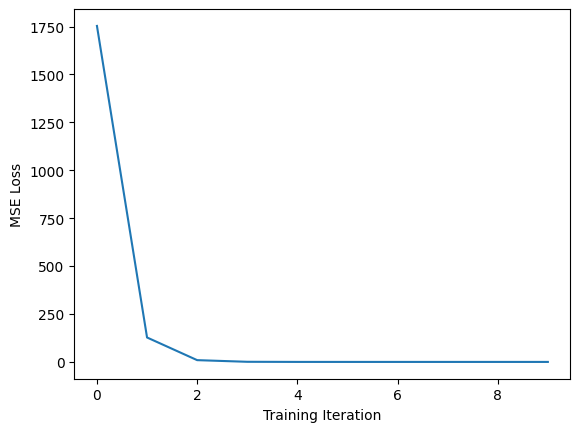

In [46]:
plt.plot(losses)
plt.xlabel('Training Iteration')
plt.ylabel('MSE Loss')
plt.show()

Let's visualise the parameters:

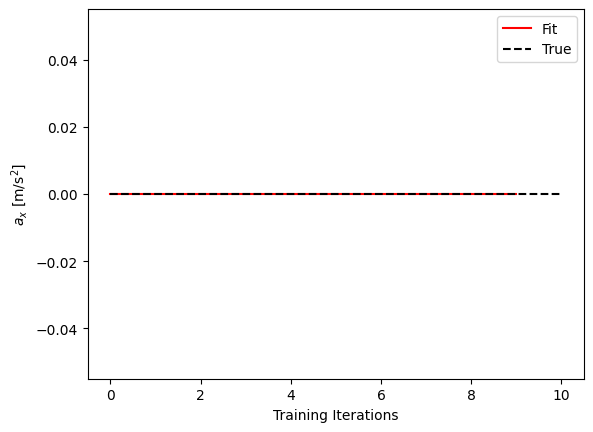

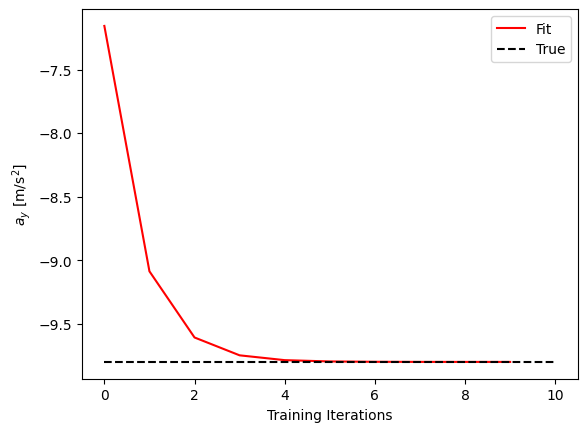

In [47]:
plt.plot(torch.cat(a_steps)[:, 0], c='r', label='Fit')
plt.plot([0, len(a_steps)], [a_target[0][0]]*2, c='k', ls='dashed', label='True')
plt.xlabel('Training Iterations')
plt.ylabel('$a_x$ [m/s$^2$]')
plt.legend()
plt.show()

plt.plot(torch.cat(a_steps)[:, 1], c='r', label='Fit')
plt.plot([0, len(a_steps)], [a_target[0][1]]*2, c='k', ls='dashed', label='True')
plt.xlabel('Training Iterations')
plt.ylabel('$a_y$ [m/s$^2$]')
plt.legend()
plt.show()

## Task 1+: Simultaneously optimize multiple parameters!

Let's fit all parameters, including model parameters and model inputs, altogether through differentiable simulation!
The training loop is similar to before.

In [51]:
# Initialize training parameters. This time we want gradients for a, x0, and v0
a_sim = torch.tensor([0., 0.])[None, :]
x0_sim = torch.tensor([0.,0.])[None, :]
v0_sim = torch.tensor([0., 0.])[None, :]

a_sim.requires_grad = True
x0_sim.requires_grad = True
v0_sim.requires_grad = True

# Learning rate -- controls the size of the optimization step

# Keep track of training and losses 
training_path = []
losses = []

# Do 10 parameter updates
for epoch in tqdm(range(10000)):   
    
    for param in [v0_sim, x0_sim, a_sim]:
        if param.grad is not None:
            param.grad.zero_()

    # Guess with current parameters
    trajectory_sim = position(time_steps, a_sim, x0_sim, v0_sim)
    
    # Calculate loss
    loss = ((trajectory_data - trajectory_sim)**2).mean()
    
    # Compute gradients
    loss.backward()
    
    # Update for next loop -- simultaneous update of all three
    with torch.no_grad():
        v0_sim -= lr*v0_sim.grad
        x0_sim -= lr*x0_sim.grad
        a_sim -= lr*a_sim.grad

    # Store training history.
    training_path.append(trajectory_sim.detach())
    losses.append(loss.detach())

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:04<00:00, 2244.57it/s]


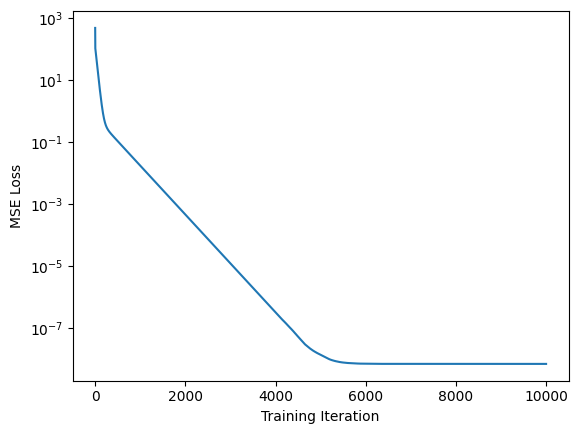

In [52]:
plt.plot(losses)
plt.xlabel('Training Iteration')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.show()

In [53]:
print(losses[-1])

tensor(7.1872e-09)


Inspect the fitted simulation output vs. data.

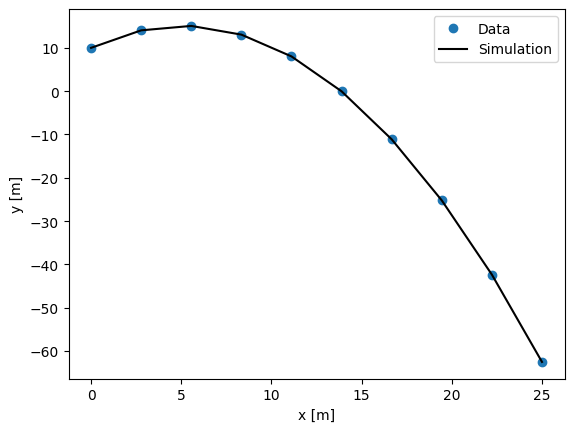

In [54]:
# plot target data trajectory
plt.plot(trajectory_data[:, 0], trajectory_data[:, 1], 'o', label='Data')

# plot the last iteration of the simulated trajectory
plt.plot(training_path[-1][:, 0], training_path[-1][:, 1], c='k', label='Simulation')
plt.legend()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()

In [55]:
print(f'Final v0: {v0_sim.detach()[0]}, Target: {v0_target[0]}')
print(f'Final x0: {x0_sim.detach()[0]}, Target: {x0_target[0]}')
print(f'Final a: {a_sim.detach()[0]}, Target: {a_target[0]}')

Final v0: tensor([4.9999, 9.9997]), Target: tensor([ 5, 10])
Final x0: tensor([5.2815e-05, 1.0000e+01]), Target: tensor([ 0, 10])
Final a: tensor([ 2.2371e-05, -9.7999e+00]), Target: tensor([ 0.0000, -9.8000])


### Use the built-in's
We've tried manually define the loss function and optimizer. Now we can use the built-in's from PyTorch!

In [59]:
# Same MSE loss from PyTorch
loss_fn = torch.nn.MSELoss()

# If we want to initialize at 0's we should use torch.zeros
a_sim = torch.zeros((1, 2), requires_grad=True)
x0_sim = torch.zeros((1, 2), requires_grad=True)
v0_sim = torch.zeros((1, 2), requires_grad=True)

# Torch has a bunch of built in optimizers. Stick with gradient descent.
optimizer = torch.optim.SGD([a_sim, x0_sim, v0_sim], lr=0.02)

# Same simple history tracking
training_path = []
losses = []
for epoch in tqdm(range(10000)):
    # This line replaces the per-parameter gradient zeroing
    optimizer.zero_grad()
    
    # Forward model done the same way
    trajectory_sim = position(time_steps, a_sim, x0_sim, v0_sim)
    
    # Pass to loss function
    loss = loss_fn(trajectory_data, trajectory_sim)
    
    # Backward pass done the same way
    loss.backward()

    # The optimizer takes care of the gradient steps
    optimizer.step()
        
    losses.append(loss.detach())
    training_path.append(trajectory_sim.detach())

100%|██████████| 10000/10000 [00:05<00:00, 1815.69it/s]


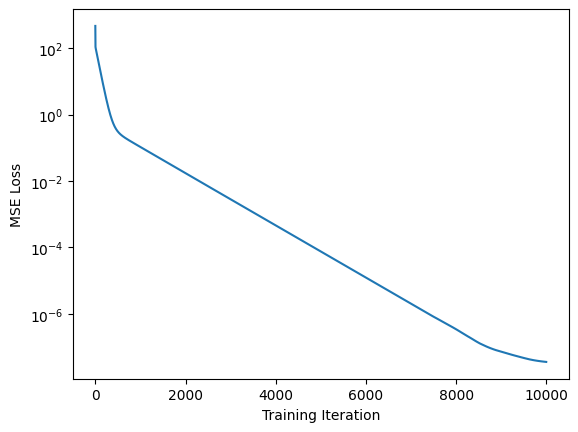

In [58]:
plt.plot(losses)
plt.xlabel('Training Iteration')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.show()

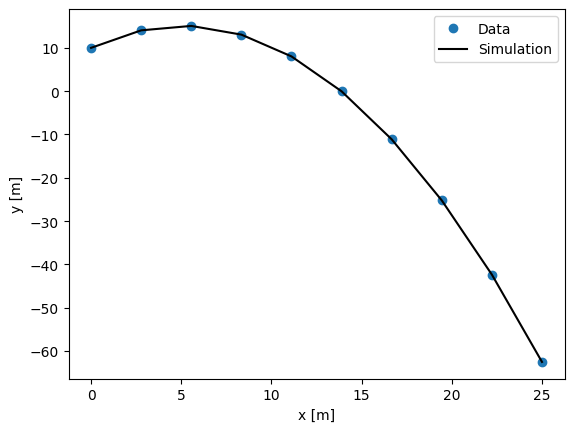

In [60]:
# plot target data trajectory
plt.plot(trajectory_data[:, 0], trajectory_data[:, 1], 'o', label='Data')

# plot the last iteration of the simulated trajectory
plt.plot(training_path[-1][:, 0], training_path[-1][:, 1], c='k', label='Simulation')
plt.legend()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()

In [61]:
print(f'Final v0: {v0_sim.detach()[0]}, Target: {v0_target[0]}')
print(f'Final x0: {x0_sim.detach()[0]}, Target: {x0_target[0]}')
print(f'Final a: {a_sim.detach()[0]}, Target: {a_target[0]}')

Final v0: tensor([4.9999, 9.9997]), Target: tensor([ 5, 10])
Final x0: tensor([5.2815e-05, 1.0000e+01]), Target: tensor([ 0, 10])
Final a: tensor([ 2.2370e-05, -9.7999e+00]), Target: tensor([ 0.0000, -9.8000])


Using PyTorch built-ins let's us easily explore other optimizers (e.g. Adam)

In [66]:
# Same MSE loss from PyTorch
loss_fn = torch.nn.MSELoss()

# If we want to initialize at 0's we should use torch.zeros
a_sim = torch.zeros((1, 2), requires_grad=True)
x0_sim = torch.zeros((1, 2), requires_grad=True)
v0_sim = torch.zeros((1, 2), requires_grad=True)

# Torch has a bunch of built in optimizers. Stick with gradient descent.
optimizer = torch.optim.Adam([a_sim, x0_sim, v0_sim], lr=0.02)

# Same simple history tracking
training_path = []
losses = []
for epoch in tqdm(range(10000)):
    # This line replaces the per-parameter gradient zeroing
    optimizer.zero_grad()
    
    # Forward model done the same way
    trajectory_sim = position(time_steps, a_sim, x0_sim, v0_sim)
    
    # Pass to loss function
    loss = loss_fn(trajectory_data, trajectory_sim)
    
    # Backward pass done the same way
    loss.backward()

    # The optimizer takes care of the gradient steps
    optimizer.step()
        
    losses.append(loss.detach())
    training_path.append(trajectory_sim.detach())

100%|██████████| 10000/10000 [00:08<00:00, 1166.98it/s]


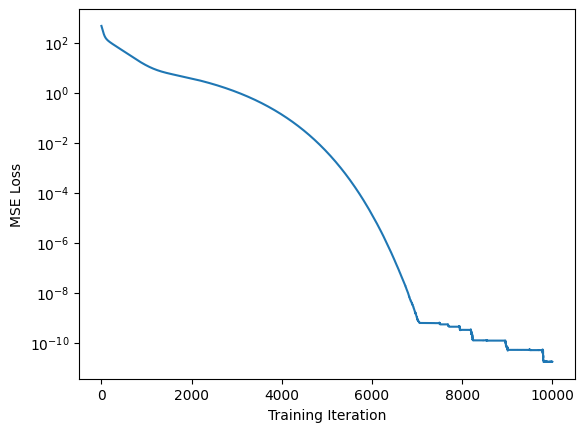

In [67]:
plt.plot(losses)
plt.xlabel('Training Iteration')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.show()

In [69]:
print(f'Final v0: {v0_sim.detach()[0]}, Target: {v0_target[0]}')
print(f'Final x0: {x0_sim.detach()[0]}, Target: {x0_target[0]}')
print(f'Final a: {a_sim.detach()[0]}, Target: {a_target[0]}')

Final v0: tensor([ 5.0000, 10.0000]), Target: tensor([ 5, 10])
Final x0: tensor([1.2471e-06, 1.0000e+01]), Target: tensor([ 0, 10])
Final a: tensor([ 4.8980e-07, -9.8000e+00]), Target: tensor([ 0.0000, -9.8000])


## Task 2: A differentiable pipeline

Let's write a differentiable pipleine connecting a physics model with a neural network, and optimize them together.

As a simple example, suppose we have a pitching machine that fires balls in a place with known acceleration, but with the initial velocity and position that become increasingly misaligned as time goes by.

We want to develop a prediction for the final position of the balls as a function of the time.

There are two ways one could do this: 

1) Train a model to go from the time to final position

2) Train a model to go from the time to initial position + velocity, use our differentiable simulator to propagate to the final position. 

Use 1D for simplicity here.

In [70]:
#Acceleration (-9.8 [m/s^2] in negative y direction)
a = torch.tensor(-9.8)

#Initial velocity [m / s]
v0_start = torch.tensor(10)

#Start at 10 [m]
x0_start = torch.tensor(15)

# End time: assume this is fixed
t_end = torch.tensor(3)

We define the position function as before

In [71]:
def position(t, a, x0, v0):
    return x0 + v0*t + 0.5*a*t**2

And now introduce some drift in v0 and x0. For simplicity, let's assume that t_launch (the time of day we're launching) runs from 0 to 1.

In [72]:
def v0_drift(t_launch):
    return 5*t_launch**2

def x0_drift(t_launch):
    return 2*torch.sin(20*t_launch)

Set up some training data for launching

In [73]:
all_t_launch = torch.linspace(0, 1, 100)
all_v0_drift = v0_drift(all_t_launch)
all_x0_drift = x0_drift(all_t_launch)

all_end = position(t_end, a, x0_start+all_x0_drift, v0_start+all_v0_drift)

Now the ending position as a function of launch time is some convoluted function:

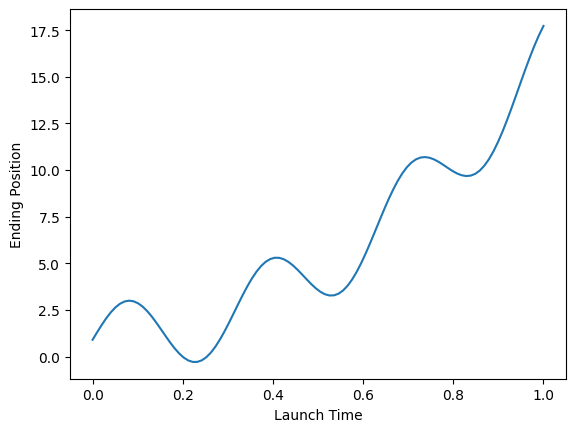

In [74]:
plt.plot(all_t_launch, all_end)
plt.xlabel('Launch Time')
plt.ylabel('Ending Position')
plt.show()

But the drift functions are relatively simple:

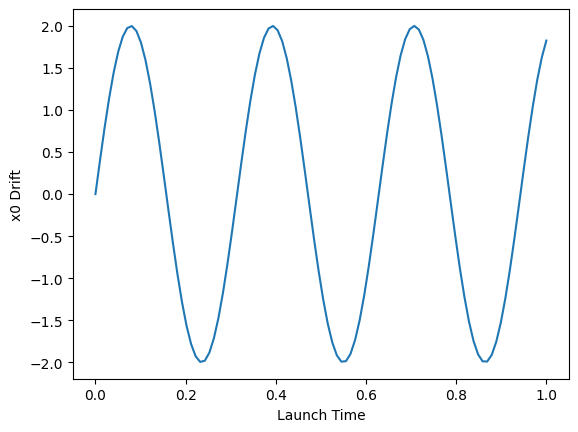

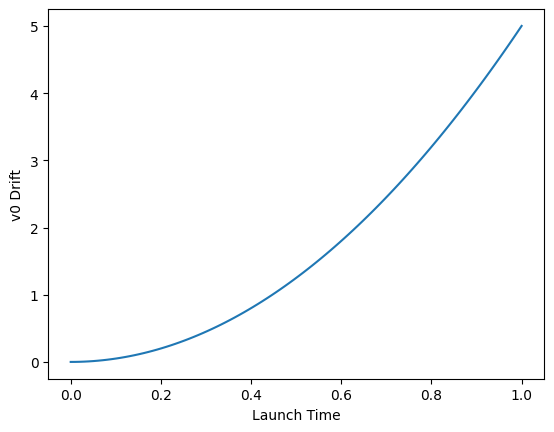

In [75]:
plt.plot(all_t_launch, all_x0_drift)
plt.xlabel('Launch Time')
plt.ylabel('x0 Drift')
plt.show()
plt.plot(all_t_launch, all_v0_drift)
plt.xlabel('Launch Time')
plt.ylabel('v0 Drift')
plt.show()

### Claim: Modeling the underlying variables may make it easier to model the objective

Let's test this out with some simple MLPs.


First, let's set up a network to directly model the end position drift:

In [76]:
from torch import nn

class MLP_direct(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layers = nn.Sequential(
                          nn.Linear(1, 100),
                          nn.ReLU(),
                          nn.Linear(100, 50),
                          nn.ReLU(),
                          nn.Linear(50, 1)
                        )


    def forward(self, x):
        out = self.layers(x)
        return out

Our inputs are the launch times, targets are the end positions:

In [77]:
inputs = all_t_launch[:, None]
targets = all_end[:, None]

Traning loop should be pretty standard

In [98]:
# Initialize the MLP
torch.random.manual_seed(3)
mlp = MLP_direct()

# Define the loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)

# Run the training loop
losses = []
predictions_direct = []
for epoch in tqdm(range(8000)): 

    # Zero the gradients
    optimizer.zero_grad()

    # Perform forward pass
    outputs = mlp(inputs)

    # Compute loss
    loss = loss_fn(outputs, targets)

    # Perform backward pass
    loss.backward()

    # Perform optimization
    optimizer.step()
    
    losses.append(loss.item())
    predictions_direct.append(outputs.flatten().clone().detach())

  0%|          | 0/8000 [00:00<?, ?it/s]

100%|██████████| 8000/8000 [00:15<00:00, 522.29it/s]


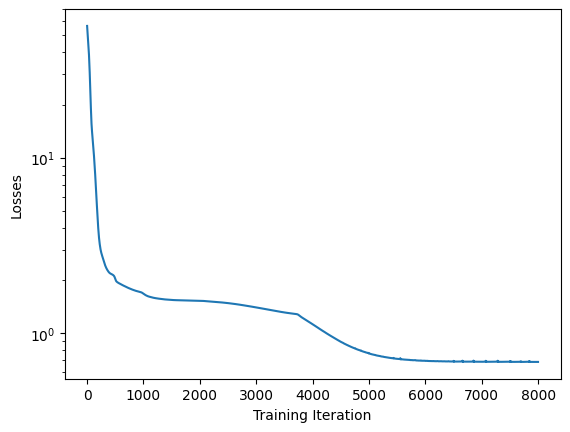

In [99]:
plt.plot(losses)
plt.xlabel('Training Iteration')
plt.ylabel('Losses')
plt.yscale('log')
plt.show()

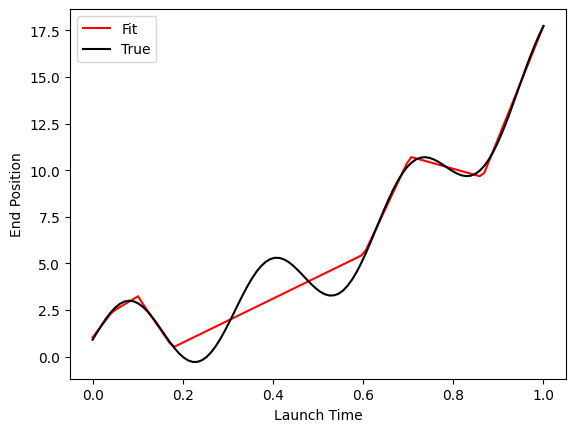

In [100]:
plt.plot(all_t_launch, predictions_direct[-1], c='r', label='Fit')
plt.plot(all_t_launch, all_end, c='k', label='True')
plt.legend()
plt.xlabel('Launch Time')
plt.ylabel('End Position')
plt.show()

Not too bad (and we could probably make it better with tweaking) but misses some fine structure!


Now with differentiable programming, we model the drift and propagate it through:

In [101]:
from torch import nn

class MLP_drift(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layers = nn.Sequential(
                          nn.Linear(1, 100),
                          nn.ReLU(),
                          nn.Linear(100, 50),
                          nn.ReLU(),
                          nn.Linear(50, 2)
                        )


    def forward(self, x):
        out = self.layers(x)
        return out

Our inputs will be the launch times and our targets will still be the end positions.

In [102]:
inputs = all_t_launch[:, None]
targets = all_end[:, None]

Training loop is the same, but with an extra step in the middle!

In [107]:
# Initialize the MLP
torch.random.manual_seed(3)
mlp = MLP_drift()

# Define the loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)

# Run the training loop
losses = []
pred_x0_drift = []
pred_v0_drift = []
final_pred_drift = []

for epoch in tqdm(range(8000)): 

    # Zero the gradients
    optimizer.zero_grad()

    # Perform forward pass to get drift
    full_drift = mlp(inputs)
    
    x0_drift = full_drift[:, 0]
    v0_drift = full_drift[:, 1]
    
    # Propagate drift through to end position
    pred = position(t_end, a, x0_start+x0_drift, v0_start+v0_drift)[:, None]

    # Compute loss
    loss = loss_fn(pred, targets)

    # Perform backward pass
    loss.backward()

    # Perform optimization
    optimizer.step()
    
    losses.append(loss.item())
    pred_x0_drift.append(x0_drift.flatten().clone().detach())
    pred_v0_drift.append(v0_drift.flatten().clone().detach())
    final_pred_drift.append(pred.flatten().clone().detach())

  0%|          | 0/8000 [00:00<?, ?it/s]

100%|██████████| 8000/8000 [00:19<00:00, 415.56it/s]


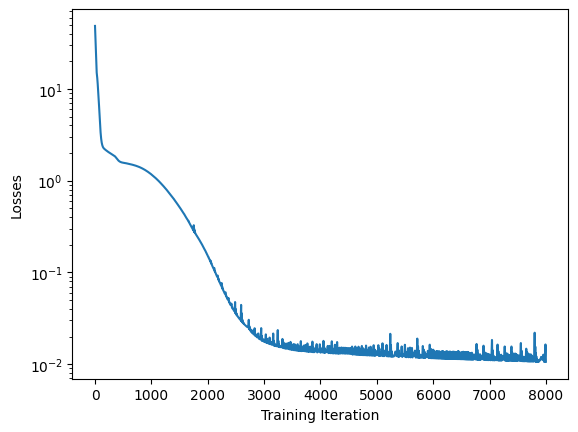

In [108]:
plt.plot(losses)
plt.xlabel('Training Iteration')
plt.ylabel('Losses')
plt.yscale('log')
plt.show()

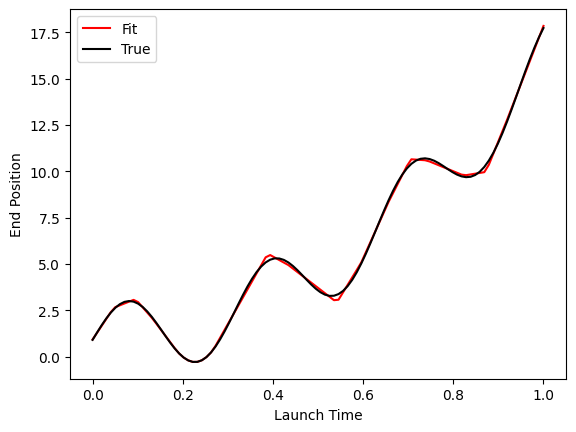

In [109]:
plt.plot(all_t_launch, final_pred_drift[-1], c='r', label='Fit')
plt.plot(all_t_launch, all_end, c='k', label='True')
plt.legend()
plt.xlabel('Launch Time')
plt.ylabel('End Position')
plt.show()

Not perfect, but much better! Let's see how the parameters look:

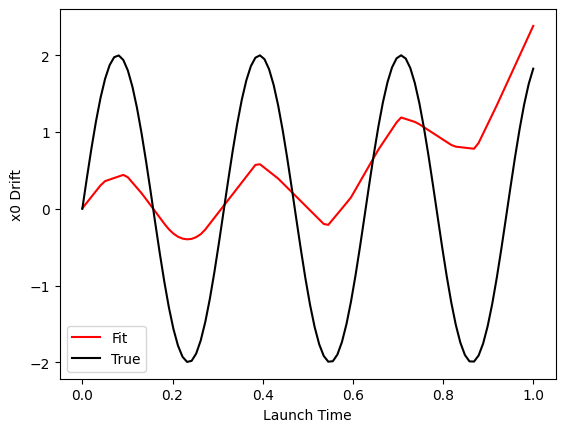

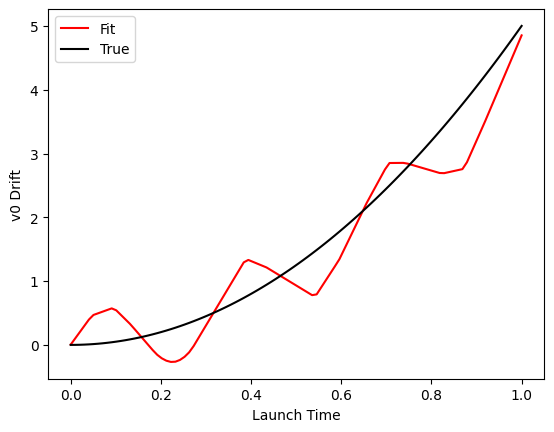

In [110]:
plt.plot(all_t_launch, pred_x0_drift[-1], c='r', label='Fit')
plt.plot(all_t_launch, all_x0_drift, c='k', label='True')
plt.xlabel('Launch Time')
plt.ylabel('x0 Drift')
plt.legend()
plt.show()

plt.plot(all_t_launch, pred_v0_drift[-1], c='r', label='Fit')
plt.plot(all_t_launch, all_v0_drift, c='k', label='True')
plt.xlabel('Launch Time')
plt.ylabel('v0 Drift')
plt.legend()
plt.show()

**Cautionary tale:** model _degeneracies_ may lead to unexpected results! But including physics can still help (e.g. extra (physical) degrees of freedom). Degeneracies may be broken with _additional constraints_.

## Tips and Tricks: Sharp Edges

We now know how to fit parameters of a physics simulation using differentiable programming. But...our simulation is quite simple. What happens if it is more complex? What about if it's not trivially differentiable? 


Let's walk through an example where we want to make a cut on an observable to maximize a single binned significance ("cut and count"). For simplicity, we set this up as follows:


Suppose we have 500 total signal events ($s$) and 10000 total background events ($b$) with mass distributions peaked in distinct spots ($\mathbb{E}[m_{s}] = 1100$ GeV and $\mathbb{E}[m_{b}] = 700$ GeV). We want to find a cut value on $m$ that maximizes $s/\sqrt{b}$.

In [111]:
# Create the toy data
n_s = 500
n_b = 10000

torch.random.manual_seed(3)
m_s = 1000*torch.normal(torch.ones(n_s)*0.6, torch.ones(n_s)*0.05)+500
m_b = 1000*torch.normal(torch.ones(n_b)*0.2, torch.ones(n_b)*0.3)+500

# Concatenate to one vector of observable values
all_ms = torch.cat([m_s, m_b])

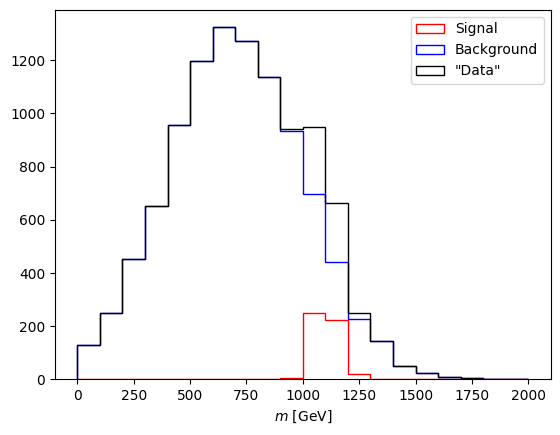

In [112]:
# Plot the distributions
plt.hist(m_s.numpy(), bins=20, range=[0, 2000], histtype='step', edgecolor='r', label='Signal')
plt.hist(m_b.numpy(), bins=20, range=[0, 2000], histtype='step', edgecolor='b', label='Background')

plt.hist(all_ms.numpy(),  bins=20, range=[0, 2000], histtype='step', edgecolor='k', label='"Data"')
plt.xlabel('$m$ [GeV]')
plt.legend()
plt.show()

We want to make a cut and maximize $s/\sqrt{b}$ for the remaining events. As an example:

In [113]:
# Pick a cut value
a = torch.tensor(500.)

# Number of signal events passing cut
n_s_pass = (m_s >= a).sum()

# Number of background events passing cut
n_b_pass = (m_b >= a).sum()

# s/sqrt(b)
print(n_s_pass/torch.sqrt(n_b_pass))

tensor(5.7862)


This is a 1D example, so we can construct the ground truth by just sweeping over values:

In [114]:
test_as = torch.linspace(500, 1500, 10000)

Remember the trick from before of adding singular `x[None, :]` type dimensions to make shapes work out. 

Specifically, we wanted to calculate over all time steps and each spatial dimension at the same time, so we had shapes like:
```
# Start at (0,10) [m]
x0_target = torch.tensor([0,10])[None, :]

# Data taken at 10 known timesteps from 0 to 5 s
time_steps = torch.linspace(0, 5, 10)[:, None]
```

so that we ended up with a tensor of shape (n_time_steps, n_space) = (10, 2)

Can we calclulate `n_s` in a similar way to compare all values of `m_s` with all cuts (values of `test_as`)? 

Specifically, we want to end up with a tensor of shape `(len(m_s), len(test_as))` which we can then sum over `dim=0`.

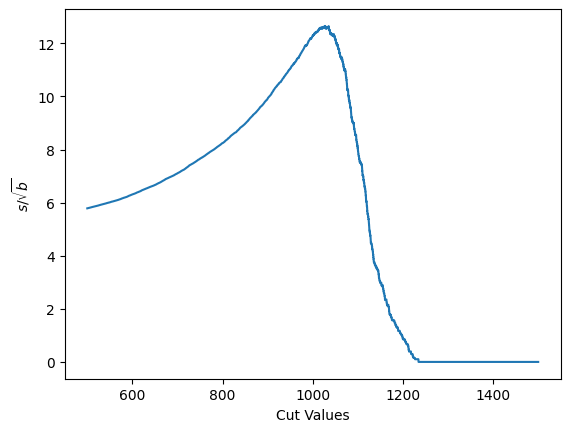

Best cut: 1027.4527587890625, s/sqrt(b): 12.658792495727539


In [115]:
all_n_s = (m_s[:, None] >= test_as[None, :]).sum(dim=0)
all_n_b = (m_b[:, None] >= test_as[None, :]).sum(dim=0)

all_sig = all_n_s/torch.sqrt(all_n_b)

plt.plot(test_as, all_sig)
plt.xlabel('Cut Values')
plt.ylabel('$s/\\sqrt{b}$')
plt.show()

best_idx = torch.argmax(all_sig)
print(f'Best cut: {test_as[best_idx]}, s/sqrt(b): {all_sig[best_idx]}')

### Problem statement:
Can we use differentiable programming + gradient-based optimization to find the cut value that maximizes $s/\sqrt{b}$?


Let's break down the function that we're trying to optimize (remember, autodiff is the chain rule).


For a given value of cut $a$, event with mass $m$, we first need to check if $m$ > $a$. If yes, it contributes to the event count, if no, it doesn't.

One way of representing this is via a piecewise function
\begin{equation}
    p(m) = 
    \begin{cases} 
      1 & m \geq a \\
      0 & m < a
    \end{cases}
\end{equation}

Plotting:

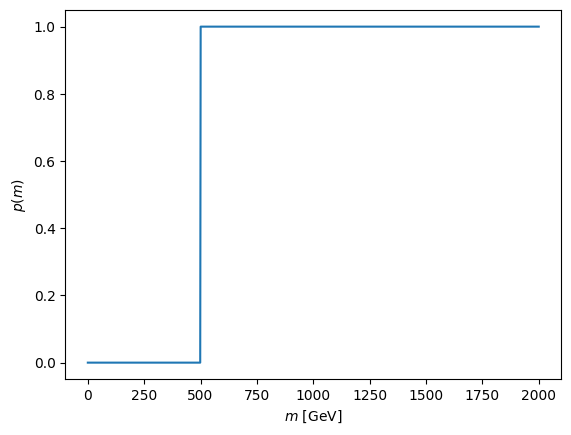

In [116]:
a = 500.
m_vals = torch.linspace(0, 2000, 1000)

plt.plot(m_vals, (m_vals>=a).int())
plt.xlabel('$m$ [GeV]')
plt.ylabel('$p(m)$')
plt.show()

This is the form of the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function).

One problem: what is the derivative, $\frac{dp(m)}{dm}$? If we look at the form of the function, we see it's 0 everywhere (and infinite at one point) -- not very useful for optimization!

On the code side, there's also a bit of an issue

In [117]:
# Pick a cut value
a = torch.tensor(500., requires_grad=True)

# Number of signal events passing cut
n_s_pass = (m_s >= a).sum()

# Number of background events passing cut
n_b_pass = (m_b >= a).sum()

# s/sqrt(b)
print(n_s_pass/torch.sqrt(n_b_pass))

tensor(5.7862)


Usually we have an associated grad_fn, e.g.:

In [118]:
a*2

tensor(1000., grad_fn=<MulBackward0>)

But that's not the case here (and for good reason). One common approach to this type of issue is to use some _relaxation_ of the hard edge/discrete cut -- some function with nicer derivatives that is close to (but not exactly) the function of interest.

For step-function like functions, a good choice is the sigmoid:

\begin{equation}
S_{k}(x) = \frac{1}{1+e^{-k\cdot x}}
\end{equation}

where $k$ is a rate parameter that controls the steepness of the transition from 0 to 1.

In [119]:
def soft_gt(x, a, rate=1.):
    return torch.sigmoid(rate*(x-a))

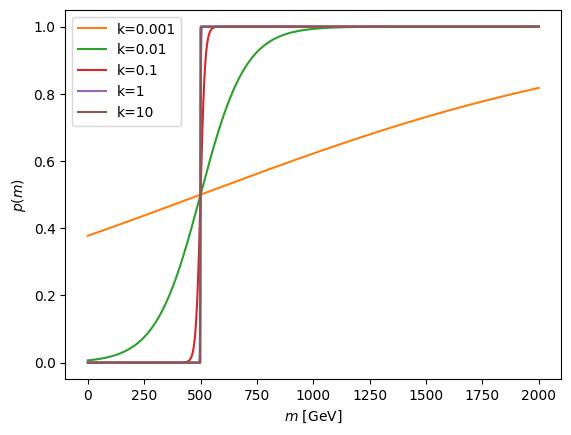

In [120]:
a = 500.
m_vals = torch.linspace(0, 2000, 1000)

plt.plot(m_vals, (m_vals>=a))
for rate in [1e-3, 1e-2, 0.1, 1, 10]:
    plt.plot(m_vals, soft_gt(m_vals, a, rate=rate), label=f'k={rate}')
plt.xlabel('$m$ [GeV]')
plt.ylabel('$p(m)$')
plt.legend()
plt.show()

We can tune the rate parameter to trade off between accuracy (how close we are to the hard cut) and smoothness (how good the gradients are).



In context:

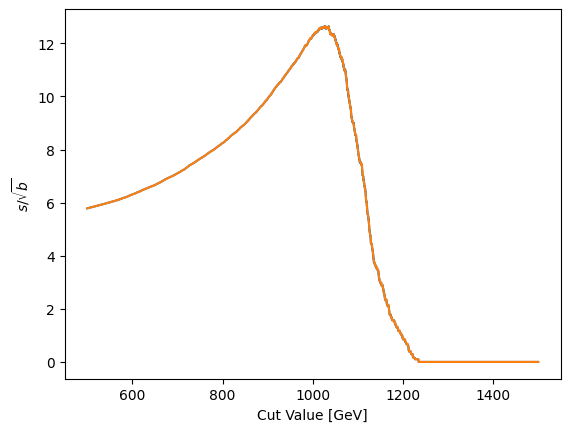

Best cut, soft: 1027.352783203125, true sig: 12.65429973602295
Best cut, exact: 1027.4527587890625, true sig: 12.658792495727539


In [121]:
# Choose some rate (may need to adjust)
rate=10.

# Calculate s/sqrt(b) with the soft greater than
all_n_s_soft = soft_gt(m_s[:, None], test_as[None, :], rate=rate).sum(dim=0)
all_n_b_soft = soft_gt(m_b[:, None], test_as[None, :], rate=rate).sum(dim=0)

all_sig_soft = all_n_s_soft/torch.sqrt(all_n_b_soft)

# Compare to the exact version
plt.plot(test_as, all_sig, label='Exact')
plt.plot(test_as, all_sig_soft, label='Softened')
plt.ylabel("$s/\\sqrt{b}$")
plt.xlabel("Cut Value [GeV]")
plt.show()
print(f'Best cut, soft: {test_as[np.argmax(all_sig_soft)]}, true sig: {all_sig[np.argmax(all_sig_soft)]}')
print(f'Best cut, exact: {test_as[np.argmax(all_sig)]}, true sig: {all_sig[np.argmax(all_sig)]}')

Let's check that gradients flow now:

In [122]:
rate=10.
# Pick a cut value
a = torch.tensor(500., requires_grad=True)

# Number of signal events passing cut
n_s_pass_soft = soft_gt(m_s, a, rate=rate).sum()

# Number of background events passing cut
n_b_pass_soft = soft_gt(m_b, a, rate=rate).sum()

# s/sqrt(b)
print(n_s_pass_soft/torch.sqrt(n_b_pass_soft))

tensor(5.7862, grad_fn=<DivBackward0>)


Success! Let's try running an optimization:

In [123]:
# Initial guess
a = torch.tensor(500., requires_grad=True)

optimizer = torch.optim.Adam([a], lr=1)

# History tracking
a_history = []
losses = []
for epoch in tqdm(range(2000)):
    optimizer.zero_grad()
    
    # Calculate s/sqrt(b)
    n_s_pass_soft = soft_gt(m_s, a, rate=rate).sum()
    n_b_pass_soft = soft_gt(m_b, a, rate=rate).sum()

    sig = n_s_pass_soft/torch.sqrt(n_b_pass_soft)
    
    # We want to maximize sig -- so minimize -sig
    loss = -sig
    loss.backward()

    # The optimizer takes care of the gradient steps
    optimizer.step()
        
    losses.append(loss.item())
    a_history.append(a.item())

100%|██████████| 2000/2000 [00:02<00:00, 908.87it/s]


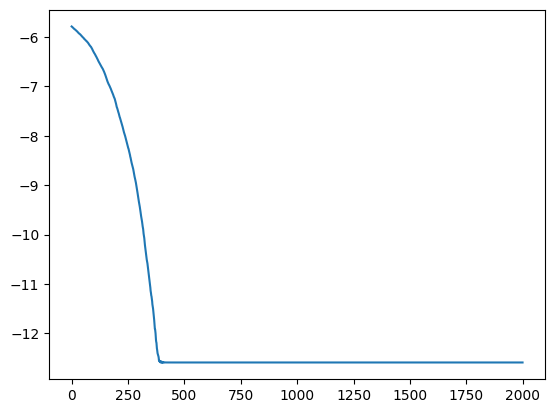

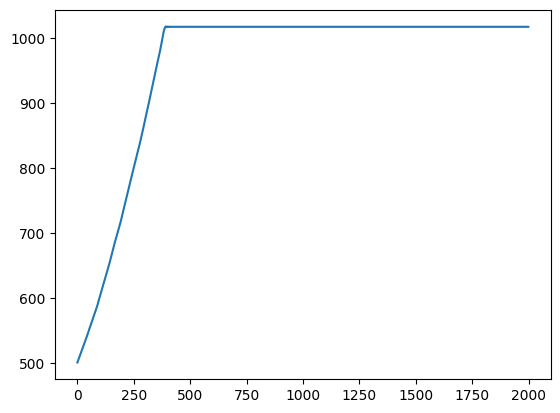

Converged: 1017.1522216796875 12.588496208190918
Sweep: 1027.4527587890625 12.658792495727539


In [124]:
plt.plot(losses)
plt.show()
plt.plot(a_history)
plt.show()
print('Converged:', a_history[-1], -losses[-1])
print('Sweep:', test_as[torch.argmax(all_sig)].item(), all_sig[torch.argmax(all_sig)].item())

In [125]:
a_fit = a_history[-1]

# Number of signal events passing fit cut
n_s_pass_fit = (m_s >= a_fit).sum()

# Number of background events passing fit cut
n_b_pass_fit = (m_b >= a_fit).sum()

# s/sqrt(b)
print(f'True sig. at fit cut: {(n_s_pass_fit/torch.sqrt(n_b_pass_fit)).item()}')

True sig. at fit cut: 12.59333610534668


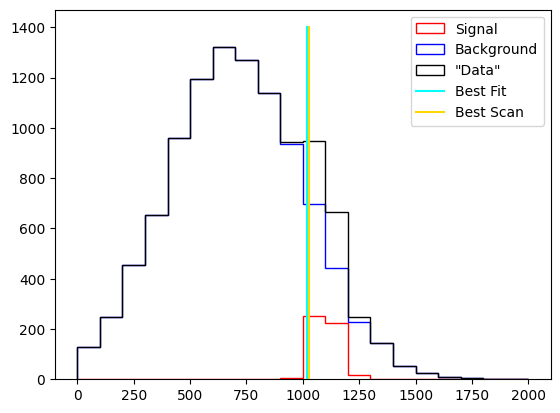

In [126]:
plt.hist(m_s.numpy(), bins=20, range=[0, 2000], edgecolor='r', histtype='step', label='Signal')
plt.hist(m_b.numpy(), bins=20, range=[0, 2000], edgecolor='b', histtype='step', label='Background')

plt.hist(all_ms.numpy(),  bins=20, range=[0, 2000], edgecolor='k', histtype='step', label='"Data"')

plt.plot([a_history[-1]]*2, [0, 1400], label='Best Fit', c='cyan')
plt.plot([test_as[best_idx]]*2, [0, 1400], label='Best Scan', c='gold')
plt.legend()
plt.show()

### Exercises for later:

1) Impact of the rate: How big can you make the rate before the optimization breaks? What happens to accuracy as you make the rate smaller?

2) In 1D this is really a toy problem, but what about in N-D? Consider a system defined by two masses, e.g.
```
    m_s1 = 1000*torch.normal(torch.ones(n_s)*0.6, torch.ones(n_s)*0.05)+500
    m_s2 = 1000*torch.normal(torch.ones(n_s)*0.5, torch.ones(n_s)*0.1)+500
    
    m_b1 = 1000*torch.normal(torch.ones(n_b)*0.2, torch.ones(n_b)*0.3)+500
    m_b2 = 1000*torch.normal(torch.ones(n_b)*0.1, torch.ones(n_b)*0.4)+500
```
Can you run the same sort of analysis?
